2024-12-04 17:36:00,692 - Total processing time: 0.07 seconds


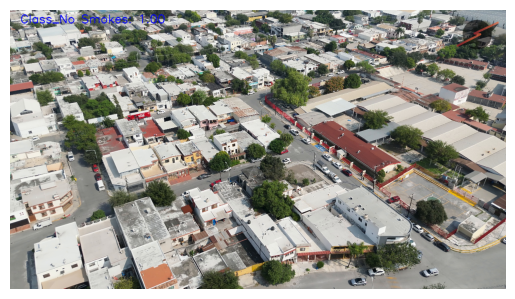

In [59]:
import torch
import cv2
import time
import logging
from pydantic import BaseModel, field_validator
from typing import Any
from PIL import Image
import torch
from torchvision import models, transforms
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn


# Assuming these paths and constants are set correctly
MODEL_PATH = r"C:\Users\Spacelab3\Desktop\envs\Classifier\smoke_classification_model_40_night.pth"  # Path to the ResNet model
LOGO_PATH = r"C:\Users\Spacelab3\Desktop\envs\Classifier\assets\logo.png"  # Path to the logo
ICON_PERSONA_PATH = r"C:\Users\Spacelab3\Desktop\envs\Classifier\assets\icons\smoke.png"  # Path to persona icon

class ModelManager:
    """
    Loads the appropriate model for image classification based on the task type
    and allocates the device (GPU or CPU).
    """
    def __init__(self):

        # Define image transformation pipeline for preprocessing
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
    
    def get_model(self, model_path):
        """
        Returns the ResNet model for classification.
        """
        self.model = models.resnet18(pretrained=True)
        self.model.fc = nn.Linear(self.model.fc.in_features, 1000)  # Adjust to match the original model's output units
        self.model.load_state_dict(torch.load(model_path)) # strict = False
        self.model.eval()

        return self.model

    def predict(self, frame: np.ndarray):
        """
        Predict the class of the image using the ResNet model.

        :param frame: The input image for classification.
        :return: Predicted class label and probability.
        """
        input_tensor = self.transform(frame).unsqueeze(0)
        with torch.no_grad():
            output = self.model(input_tensor)
        
        probabilities = torch.nn.functional.softmax(output, dim=1)
        predicted_class = torch.argmax(probabilities, dim=1).item()
        predicted_prob = probabilities[0, predicted_class].item()
        
        return predicted_class, predicted_prob

class OverlayUtils:
    """
    Handles the addition of logos, icons, and class labels to frames.
    """
    def __init__(self):
        self.logo = cv2.imread(LOGO_PATH, cv2.IMREAD_UNCHANGED)
        self.icons = {
            "persona": cv2.imread(ICON_PERSONA_PATH, cv2.IMREAD_UNCHANGED),
        }
        
    def add_logo(self, frame: np.ndarray, position='top-right', logo_transparency=0.4) -> np.ndarray:
        """
        Resize and add the logo to the frame with transparency.

        :param frame: The frame to which the overlay will be added.
        :param position: Position to place the logo ('top-left', 'top-right', etc.).
        :param logo_transparency: Transparency level of the logo.
        :return: Frame with the logo overlay.
        """
        frame_height, frame_width = frame.shape[0], frame.shape[1]
        scale = 0.2
        scale_factor = min(frame_width, frame_height) * scale
        logo_size = (int(scale_factor), int(scale_factor))
        logo_resized = cv2.resize(self.logo, logo_size)

        logo_height, logo_width = logo_resized.shape[0], logo_resized.shape[1]
        positions = {
            'top-left': (0, 0),
            'top-right': (frame_width - logo_width - 0, 0),
            'bottom-left': (10, frame_height - logo_height),
            'bottom-right': (frame_width - logo_width, frame_height - logo_height),
        }
        top_left_x, top_left_y = positions.get(position, (0, 0))

        logo_rgb = logo_resized[:, :, :3]
        logo_alpha = logo_resized[:, :, 3] / 255.0 * (1 - logo_transparency)
        
        roi = frame[top_left_y:top_left_y + logo_height, top_left_x:top_left_x + logo_width].copy()
        blended = (logo_rgb * logo_alpha[..., None] + roi * (1 - logo_alpha[..., None])).astype(np.uint8)
        frame[top_left_y:top_left_y + logo_height, top_left_x:top_left_x + logo_width] = blended

        return frame

    def add_class_label(self, frame: np.ndarray, class_name: str, prob: float) -> np.ndarray:
        """
        Adds the predicted class label and probability to the frame.

        :param frame: The frame to which the overlay will be added.
        :param class_name: The name of the predicted class.
        :param prob: The probability of the prediction.
        :return: Frame with the class label overlay.
        """
        label = f"{class_name}: {prob:.2f}"
        cv2.putText(frame, label, (80, 100), cv2.FONT_HERSHEY_SIMPLEX, 3, (255, 0, 0), 5)
        return frame

class Validator(BaseModel):
    """
    Ensures that the frame is correctly formatted and valid.
    """
    frame: Any

    @field_validator("frame")
    def frame_validation(cls, value):
        if not isinstance(value, np.ndarray) or value.size == 0:
            raise ValueError("Frame must be a non-empty ndarray")
        return value

class ImageClassificationProcessor:
    """
    Processes an image using a ResNet model, applies classification, and overlays results.
    """
    def __init__(self):
        self.model_manager = ModelManager()
        self.active_model = self.model_manager.get_model(model_path=MODEL_PATH)
        self.overlay_utils = OverlayUtils()

    def process_frame(self, frame: np.ndarray) -> np.ndarray:
        """
        Processes a frame, performs image classification, and adds overlays.

        :param frame: The frame to be processed.
        :return: Frame with classification results and overlays.
        """
        #  Convert the NumPy array frame from cv2 to a PIL Image
        image = Image.fromarray(frame)

        predicted_class, predicted_prob = self.model_manager.predict(image)
        
        # Convert predicted class to a human-readable label
        class_array = ["No Smokes","Smokes"]
        class_name = "Class_" + class_array[int(predicted_class)]  # You can map it to a real label if you have the labels.
        
        # Add overlays (logo and class label)
        frame_with_logo = self.overlay_utils.add_logo(frame)
        annotated_frame = self.overlay_utils.add_class_label(frame_with_logo, class_name, predicted_prob)

        return annotated_frame

if __name__ == "__main__":
    # Test the image classification processor
    ia_frame_processor = ImageClassificationProcessor()
    IMAGE_PATH = "C:/Users/Spacelab3/Desktop/envs/Classifier/VideoTest2/VideoTestVideo_Frame_67.jpg"
    frame = cv2.imread(IMAGE_PATH)
        
    start_time = time.time()
    ann_frame = ia_frame_processor.process_frame(frame)
    end_time = time.time()

    processing_time = end_time - start_time
    logging.info(f"Total processing time: {processing_time:.2f} seconds")

    resize_ann_frame = cv2.resize(ann_frame, (1280, 720))
    plt.imshow(cv2.cvtColor(resize_ann_frame, cv2.COLOR_BGR2RGB))
    plt.axis('off')  # Hides the axes and ticks
    plt.show()


In [5]:
import torch
import cv2
import os
import time
import logging
from pydantic import BaseModel, field_validator
from typing import Any
from PIL import Image
from torchvision import models, transforms
import torch.nn as nn
import numpy as np


# Assuming these paths and constants are set correctly
MODEL_PATH = r"C:\Users\Spacelab3\Desktop\envs\Classifier\smoke_classification_model_40_night.pth"  # Path to the ResNet model
LOGO_PATH = r"C:\Users\Spacelab3\Desktop\envs\Classifier\assets\logo.png"  # Path to the logo
ICON_PERSONA_PATH = r"C:\Users\Spacelab3\Desktop\envs\Classifier\assets\icons\smoke.png"  # Path to persona icon

class ModelManager:
    """
    Loads the appropriate model for image classification based on the task type
    and allocates the device (GPU or CPU).
    """
    def __init__(self):
        # Define image transformation pipeline for preprocessing
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
    
    def get_model(self, model_path):
        """
        Returns the ResNet model for classification.
        """
        self.model = models.resnet18(pretrained=True)
        self.model.fc = nn.Linear(self.model.fc.in_features, 1000)  # Adjust to match the original model's output units
        self.model.load_state_dict(torch.load(model_path)) # strict = False
        self.model.eval()

        return self.model

    def predict(self, frame: np.ndarray):
        """
        Predict the class of the image using the ResNet model.

        :param frame: The input image for classification.
        :return: Predicted class label and probability.
        """
        input_tensor = self.transform(frame).unsqueeze(0)
        with torch.no_grad():
            output = self.model(input_tensor)
        
        probabilities = torch.nn.functional.softmax(output, dim=1)
        predicted_class = torch.argmax(probabilities, dim=1).item()
        predicted_prob = probabilities[0, predicted_class].item()
        
        return predicted_class, predicted_prob

class OverlayUtils:
    """
    Handles the addition of logos, icons, and class labels to frames.
    """
    def __init__(self):
        self.logo = cv2.imread(LOGO_PATH, cv2.IMREAD_UNCHANGED)
        self.icons = {
            "persona": cv2.imread(ICON_PERSONA_PATH, cv2.IMREAD_UNCHANGED),
        }
        
    def add_logo(self, frame: np.ndarray, position='top-right', logo_transparency=0.4) -> np.ndarray:
        """
        Resize and add the logo to the frame with transparency.

        :param frame: The frame to which the overlay will be added.
        :param position: Position to place the logo ('top-left', 'top-right', etc.).
        :param logo_transparency: Transparency level of the logo.
        :return: Frame with the logo overlay.
        """
        frame_height, frame_width = frame.shape[0], frame.shape[1]
        scale = 0.2
        scale_factor = min(frame_width, frame_height) * scale
        logo_size = (int(scale_factor), int(scale_factor))
        logo_resized = cv2.resize(self.logo, logo_size)

        logo_height, logo_width = logo_resized.shape[0], logo_resized.shape[1]
        positions = {
            'top-left': (0, 0),
            'top-right': (frame_width - logo_width - 0, 0),
            'bottom-left': (10, frame_height - logo_height),
            'bottom-right': (frame_width - logo_width, frame_height - logo_height),
        }
        top_left_x, top_left_y = positions.get(position, (0, 0))

        logo_rgb = logo_resized[:, :, :3]
        logo_alpha = logo_resized[:, :, 3] / 255.0 * (1 - logo_transparency)
        
        roi = frame[top_left_y:top_left_y + logo_height, top_left_x:top_left_x + logo_width].copy()
        blended = (logo_rgb * logo_alpha[..., None] + roi * (1 - logo_alpha[..., None])).astype(np.uint8)
        frame[top_left_y:top_left_y + logo_height, top_left_x:top_left_x + logo_width] = blended

        return frame

    def add_class_label(self, frame: np.ndarray, class_name: str, prob: float) -> np.ndarray:
        """
        Adds the predicted class label and probability to the frame.

        :param frame: The frame to which the overlay will be added.
        :param class_name: The name of the predicted class.
        :param prob: The probability of the prediction.
        :return: Frame with the class label overlay.
        """
        label = f"{class_name}: {prob:.2f}"
        cv2.putText(frame, label, (80, 100), cv2.FONT_HERSHEY_SIMPLEX, 2, (255, 0, 0), 2)
        return frame

class ImageClassificationProcessor:
    """
    Processes an image using a ResNet model, applies classification, and overlays results.
    """
    def __init__(self):
        self.model_manager = ModelManager()
        self.active_model = self.model_manager.get_model(model_path=MODEL_PATH)
        self.overlay_utils = OverlayUtils()

    def process_frame(self, frame: np.ndarray) -> np.ndarray:
        """
        Processes a frame, performs image classification, and adds overlays.

        :param frame: The frame to be processed.
        :return: Frame with classification results and overlays.
        """
        #  Convert the NumPy array frame from cv2 to a PIL Image
        image = Image.fromarray(frame)

        predicted_class, predicted_prob = self.model_manager.predict(image)
        
        # Convert predicted class to a human-readable label
        class_array = ["No Smokes","Smokes"]
        class_name = "Class_" + class_array[int(predicted_class)]  # You can map it to a real label if you have the labels.
        
        # Add overlays (logo and class label)
        frame_with_logo = self.overlay_utils.add_logo(frame)
        annotated_frame = self.overlay_utils.add_class_label(frame_with_logo, class_name, predicted_prob)

        return annotated_frame

def create_video_from_images(image_folder, output_video_path, frame_size=(1280, 720), fps=10):
    """
    Merges images from a folder into a video.
    
    :param image_folder: Path to the folder containing images.
    :param output_video_path: Path where the video will be saved.
    :param frame_size: Desired frame size (width, height).
    :param fps: Frames per second for the video.
    """
    image_files = [f for f in os.listdir(image_folder) if f.lower().endswith(('jpg'))]
    image_files.sort()  # Sort the files to ensure correct order
    
    # Create a VideoWriter object
    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    video_writer = cv2.VideoWriter(output_video_path, fourcc, fps, frame_size)
    
    ia_frame_processor = ImageClassificationProcessor()

    for image_file in image_files:
        image_path = os.path.join(image_folder, image_file)
        frame = cv2.imread(image_path)
        
        if frame is not None:
            # Resize frame to desired size
            frame_resized = cv2.resize(frame, frame_size)
            
            # Process the frame (apply classification and overlay)
            annotated_frame = ia_frame_processor.process_frame(frame_resized)
            
            # Write the processed frame to the video
            video_writer.write(annotated_frame)
    
    # Release the video writer and finish
    video_writer.release()
    print(f"Video saved at {output_video_path}")

if __name__ == "__main__":
    image_folder = r"C:/Users/Spacelab3/Desktop/envs/Classifier/NoSmokes"  # Folder containing your images
    output_video_path = r"C:/Users/Spacelab3/Desktop/envs/Classifier/output_video_auto.avi"  # Path to save the output video

    create_video_from_images(image_folder, output_video_path)


C:\Users\Spacelab3\AppData\Local\Temp\ipykernel_9100\1056225376.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(model_path)) # str

Video saved at C:/Users/Spacelab3/Desktop/envs/Classifier/output_video_auto.avi
